# Komunitas Facebook


In [ ]:
import networkx as nx
from community import community_louvain  # python-louvain
import matplotlib.pyplot as plt

In [ ]:
with open ('facebook_combined.txt','r') as file :
  data = file.read()
print(data)

0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
0 21
0 22
0 23
0 24
0 25
0 26
0 27
0 28
0 29
0 30
0 31
0 32
0 33
0 34
0 35
0 36
0 37
0 38
0 39
0 40
0 41
0 42
0 43
0 44
0 45
0 46
0 47
0 48
0 49
0 50
0 51
0 52
0 53
0 54
0 55
0 56
0 57
0 58
0 59
0 60
0 61
0 62
0 63
0 64
0 65
0 66
0 67
0 68
0 69
0 70
0 71
0 72
0 73
0 74
0 75
0 76
0 77
0 78
0 79
0 80
0 81
0 82
0 83
0 84
0 85
0 86
0 87
0 88
0 89
0 90
0 91
0 92
0 93
0 94
0 95
0 96
0 97
0 98
0 99
0 100
0 101
0 102
0 103
0 104
0 105
0 106
0 107
0 108
0 109
0 110
0 111
0 112
0 113
0 114
0 115
0 116
0 117
0 118
0 119
0 120
0 121
0 122
0 123
0 124
0 125
0 126
0 127
0 128
0 129
0 130
0 131
0 132
0 133
0 134
0 135
0 136
0 137
0 138
0 139
0 140
0 141
0 142
0 143
0 144
0 145
0 146
0 147
0 148
0 149
0 150
0 151
0 152
0 153
0 154
0 155
0 156
0 157
0 158
0 159
0 160
0 161
0 162
0 163
0 164
0 165
0 166
0 167
0 168
0 169
0 170
0 171
0 172
0 173
0 174
0 175
0 176
0 177
0 178
0 179
0 180
0 181
0 182
0 183
0 184
0 18

## Hitung PageRank

In [ ]:
import networkx as nx

file_path = "facebook_combined.txt"
G = nx.read_edgelist(file_path, nodetype=int)

print("Jumlah Node :", G.number_of_nodes())
print("Jumlah Edge :", G.number_of_edges())

# =======================
#  PAGE RANK SELURUH GRAF
# =======================
pr = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1.0e-06)
# pr adalah dict: {node: skor_pagerank}


Jumlah Node : 4039
Jumlah Edge : 88234


## Display Network

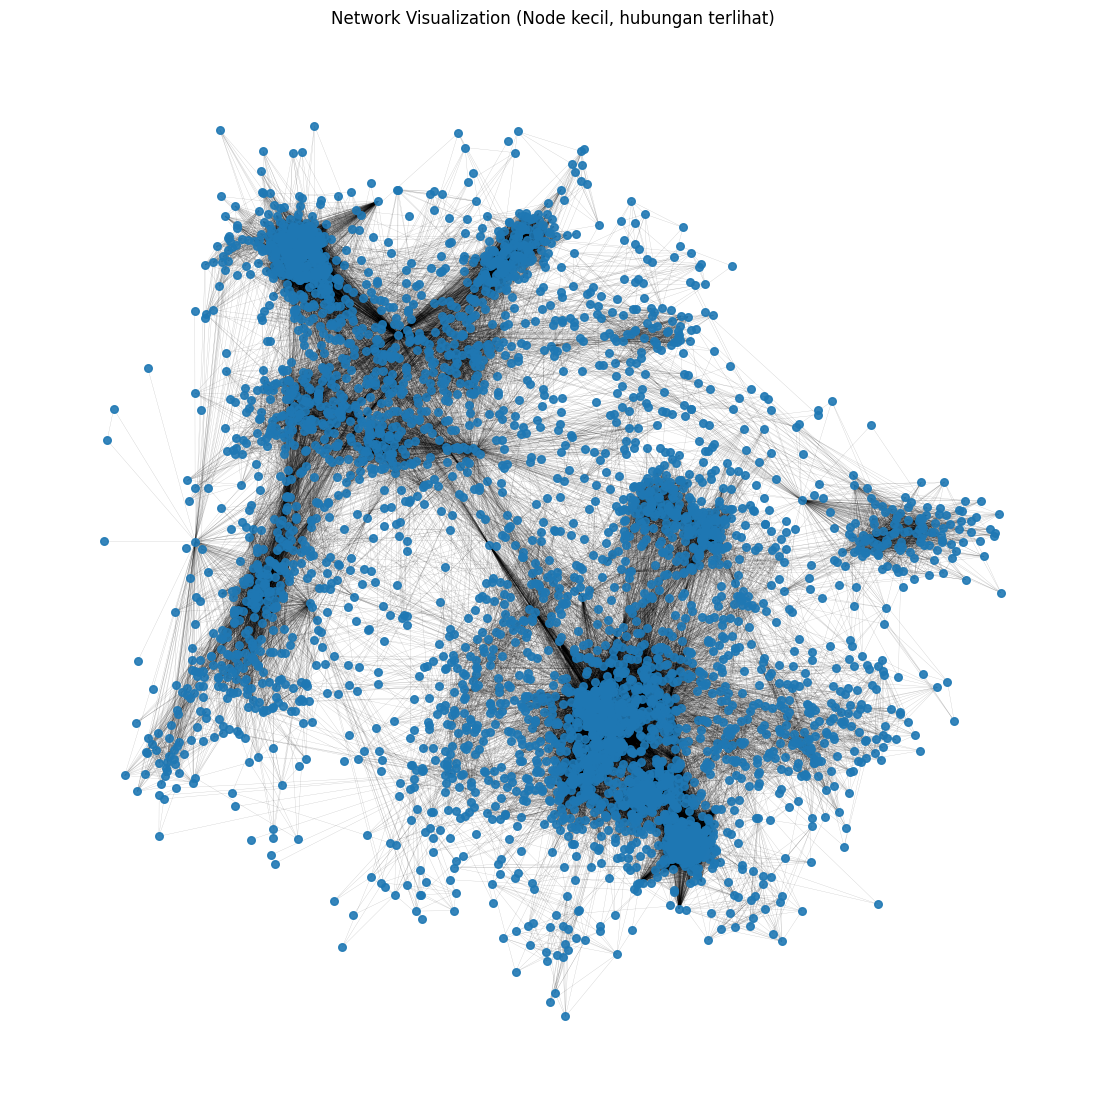

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

file_path = "facebook_combined.txt"
G = nx.read_edgelist(file_path, nodetype=int)

# layout untuk tampilan rapi
pos = nx.spring_layout(G, k=0.15, iterations=40)

plt.figure(figsize=(14, 14))

# node kecil
nx.draw_networkx_nodes(G, pos,
                       node_size=30,
                       node_color="#1f78b4",
                       alpha=0.9)

# edge tipis agar tidak terlalu gelap
nx.draw_networkx_edges(G, pos,
                       width=0.2,
                       alpha=0.25)

plt.title("Network Visualization (Node kecil, hubungan terlihat)")
plt.axis("off")
plt.show()


## Hitung Jumlah komunitas

In [ ]:
partition = community_louvain.best_partition(G)

# Jumlah komunitas
num_communities = len(set(partition.values()))
print("Jumlah Komunitas Terdeteksi:", num_communities)

Jumlah Komunitas Terdeteksi: 15


In [ ]:
modularity = community_louvain.modularity(partition, G)
print("Modularity:", modularity)

Modularity: 0.8348866638149897


In [ ]:
from collections import defaultdict

community_groups = defaultdict(list)
for node, comm in partition.items():
    community_groups[comm].append(node)

for cid, members in community_groups.items():
    print(f"Komunitas {cid} | Jumlah anggota: {len(members)}")

Komunitas 0 | Jumlah anggota: 344
Komunitas 1 | Jumlah anggota: 432
Komunitas 2 | Jumlah anggota: 560
Komunitas 7 | Jumlah anggota: 446
Komunitas 4 | Jumlah anggota: 423
Komunitas 5 | Jumlah anggota: 323
Komunitas 6 | Jumlah anggota: 117
Komunitas 8 | Jumlah anggota: 548
Komunitas 9 | Jumlah anggota: 73
Komunitas 10 | Jumlah anggota: 237
Komunitas 11 | Jumlah anggota: 25
Komunitas 12 | Jumlah anggota: 60
Komunitas 13 | Jumlah anggota: 206
Komunitas 14 | Jumlah anggota: 226
Komunitas 3 | Jumlah anggota: 19


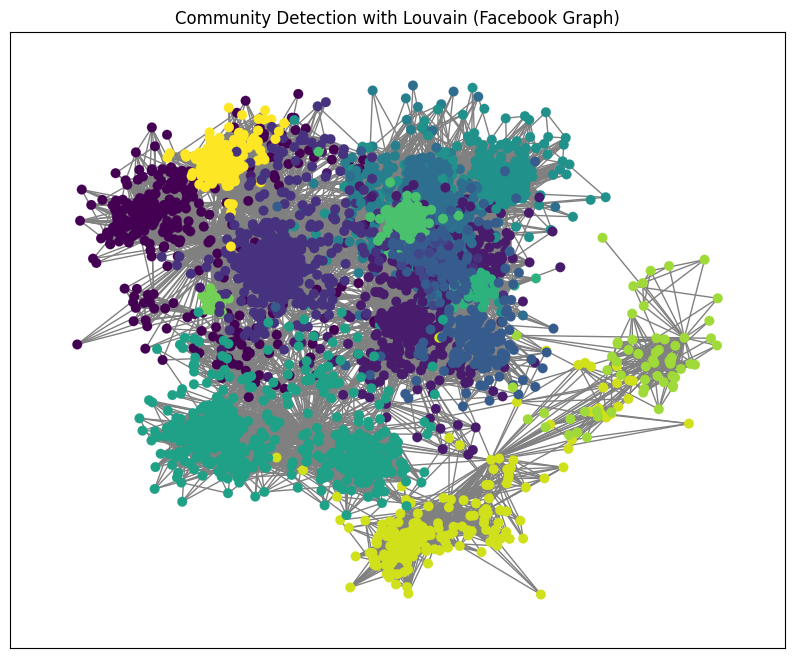

In [ ]:
sample_nodes = list(G.nodes())[:5000]
H = G.subgraph(sample_nodes)

pos = nx.spring_layout(H, seed=42)
colors = [partition[n] for n in H.nodes()]

plt.figure(figsize=(10, 8))
nx.draw_networkx(H, pos,
                 node_color=colors,
                 node_size=50,
                 edge_color='gray',
                 linewidths=0.1,
                 with_labels=False)

plt.title("Community Detection with Louvain (Facebook Graph)")
plt.show()

## keluarkan anggota anggotanya

In [ ]:
from collections import defaultdict

community_groups = defaultdict(list)
for node, comm in partition.items():
    community_groups[comm].append(node)

for cid, members in community_groups.items():
    print(f"Komunitas {cid} | Jumlah anggota: {len(members)} | Anggota: {members}")

Komunitas 0 | Jumlah anggota: 344 | Anggota: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 21

## Komunitas terbanyak dan anggotanya

In [ ]:
# Find the community with the most members
largest_community_id = -1
max_members = 0

for cid, members in community_groups.items():
    if len(members) > max_members:
        max_members = len(members)
        largest_community_id = cid

print(f"Komunitas terbanyak adalah Komunitas {largest_community_id} dengan {max_members} anggota.")
print(f"Anggota Komunitas {largest_community_id}: {community_groups[largest_community_id]}")

Komunitas terbanyak adalah Komunitas 2 dengan 560 anggota.
Anggota Komunitas 2: [58, 1684, 2814, 2838, 2885, 3003, 3173, 3290, 990, 1140, 1450, 1505, 1534, 1642, 1656, 1666, 1726, 1758, 2678, 2760, 2822, 2883, 2941, 2968, 3005, 3057, 3136, 3164, 3222, 3245, 3248, 3263, 3278, 3328, 3361, 2677, 2826, 2724, 2752, 2775, 2869, 2892, 2962, 3001, 3019, 3100, 3162, 3168, 3233, 3295, 3331, 3366, 3404, 3406, 3412, 2813, 2971, 3034, 3178, 3410, 3420, 2976, 3011, 3179, 3289, 2725, 2734, 2764, 2964, 3020, 3062, 3079, 3165, 3205, 3258, 3386, 3409, 2693, 2979, 3101, 3265, 3385, 2903, 2938, 2999, 3201, 3319, 3355, 3097, 2707, 3111, 3186, 2661, 2662, 2665, 2667, 2668, 2670, 2671, 2672, 2674, 2675, 2682, 2684, 2685, 2686, 2687, 2688, 2690, 2691, 2692, 2696, 2697, 2699, 2700, 2701, 2702, 2703, 2708, 2709, 2711, 2712, 2713, 2714, 2715, 2716, 2718, 2719, 2720, 2721, 2722, 2723, 2727, 2728, 2730, 2732, 2733, 2735, 2736, 2737, 2739, 2742, 2744, 2747, 2748, 2751, 2753, 2758, 2762, 2765, 2767, 2768, 2770, 2771

## Sub Komunitas


Plotting subgraph for Community 2 with 560 nodes and 8866 edges.


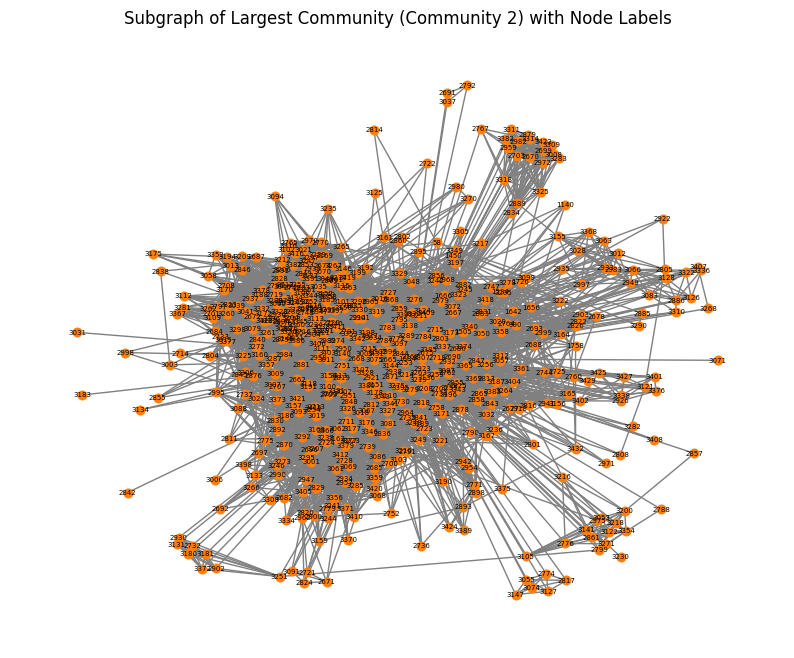

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Explicitly reload the graph to ensure it's available in this cell's context
file_path = "facebook_combined.txt"
G = nx.read_edgelist(file_path, nodetype=int)

if largest_community_id != -1 and largest_community_id in community_groups:
    largest_community_nodes = community_groups[largest_community_id]
    if len(largest_community_nodes) > 0:
        largest_community_subgraph = G.subgraph(largest_community_nodes)

        print(f"Plotting subgraph for Community {largest_community_id} with {len(largest_community_nodes)} nodes and {largest_community_subgraph.number_of_edges()} edges.")

        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(largest_community_subgraph, seed=42)  # For consistent layout
        nx.draw_networkx(
            largest_community_subgraph,
            pos,
            node_color='#ff7f0e',  # A distinct color for the largest community
            node_size=50,
            edge_color='gray',
            linewidths=0.1,
            with_labels=True, # Set to True to display node labels
            font_size=5 # Set a small font size to prevent too much overlap
        )
        plt.title(f"Subgraph of Largest Community (Community {largest_community_id}) with Node Labels")
        plt.axis("off")
        plt.show()
    else:
        print(f"Community {largest_community_id} has no members to plot.")
else:
    print("Largest community ID not found or is invalid.")